In [ ]:
from google.colab import files
uploaded = files.upload()   # upload symptom_clusters.json


Saving symptom_clusters.json to symptom_clusters (1).json


📂 Loading cluster definitions from: symptom_clusters (1).json
🔄 Generating 400 samples for 12 clusters...
✅ Total samples generated: 4800
🔄 Loading SBERT...
🔄 Encoding text with SBERT...
🚀 Training RandomForest...

✅ Train Accuracy: 0.7068
✅ Test Accuracy : 0.4906

📊 Classification Report (Test Data):

              precision    recall  f1-score   support

         low       0.36      0.31      0.34       217
      medium       0.50      0.52      0.51       422
        high       0.54      0.58      0.56       321

    accuracy                           0.49       960
   macro avg       0.47      0.47      0.47       960
weighted avg       0.49      0.49      0.49       960


🧩 Confusion Matrix:
 [[ 68 108  41]
 [ 89 218 115]
 [ 30 106 185]]


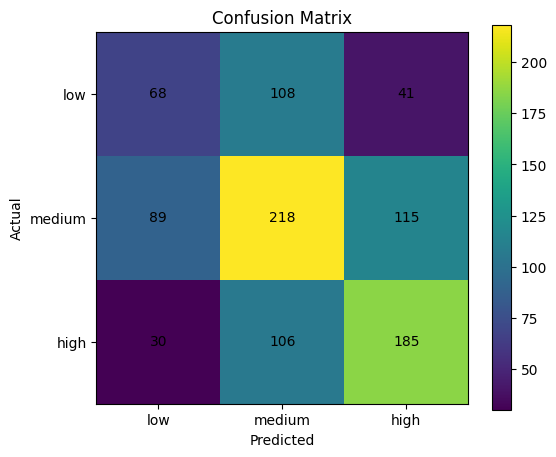

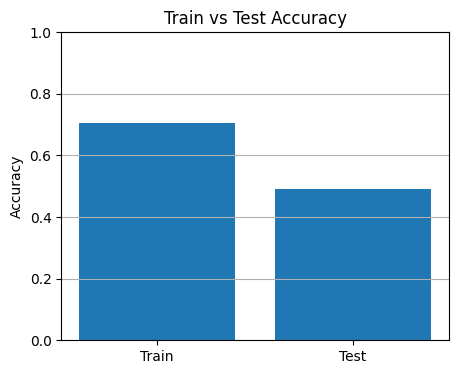


✅ Model saved as: complexity_model.pkl


In [ ]:
import json
import random
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# =====================================================
# CONFIG
# =====================================================

MODEL_NAME = "all-MiniLM-L6-v2"
OUT_MODEL = "complexity_model.pkl"

LABEL_MAP = {"low": 0, "medium": 1, "high": 2}
REVERSE_LABELS = ["low", "medium", "high"]

SAMPLES_PER_CLUSTER = 400
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# =====================================================
# LOAD CLUSTERS
# =====================================================

dataset_path = list(uploaded.keys())[0]
print(f"📂 Loading cluster definitions from: {dataset_path}")

with open(dataset_path, "r") as f:
    CLUSTERS = json.load(f)

# =====================================================
# TUNED CLUSTER PRIORS (LESS NOISE, STILL REALISTIC)
# =====================================================

CLUSTER_PRIORS = {
    "fever_general":        [0.70, 0.25, 0.05],
    "vector_borne_fever":   [0.20, 0.60, 0.20],
    "respiratory":          [0.20, 0.60, 0.20],
    "tuberculosis_suspect": [0.15, 0.55, 0.30],
    "gastrointestinal":     [0.25, 0.55, 0.20],
    "jaundice_hepatitis":   [0.20, 0.55, 0.25],
    "maternal_health":      [0.20, 0.55, 0.25],
    "pediatric_general":    [0.30, 0.50, 0.20],
    "cardiac":              [0.10, 0.30, 0.60],
    "neurological":         [0.10, 0.30, 0.60],
    "snake_scorpion_bite":  [0.10, 0.30, 0.60],
    "poisoning":            [0.10, 0.25, 0.65]
}

# =====================================================
# REALISTIC DATA GENERATION (TUNED)
# =====================================================

TEXT_FILLERS = [
    "for few days", "since yesterday", "for one week",
    "comes and goes", "worse at night", "with discomfort",
    "progressively worsening"
]

def realistic_vitals():
    return {
        "age": random.randint(1, 85),
        "spo2": random.randint(90, 99),     # slightly tighter
        "pulse": random.randint(70, 130),
        "bp_sys": random.randint(90, 150),
        "bp_dia": random.randint(60, 95)
    }

data = []

print(f"🔄 Generating {SAMPLES_PER_CLUSTER} samples for {len(CLUSTERS)} clusters...")

for cname, cinfo in CLUSTERS.items():
    if cname not in CLUSTER_PRIORS:
        continue

    keywords = cinfo.get("keywords", [])

    for _ in range(SAMPLES_PER_CLUSTER):
        # probabilistic doctor-like labeling
        label = random.choices(
            ["low", "medium", "high"],
            weights=CLUSTER_PRIORS[cname]
        )[0]

        # 🔧 STRONGER TEXT SIGNAL (3 keywords)
        sampled_words = random.sample(keywords, min(3, len(keywords)))
        text = " ".join(sampled_words) + " " + random.choice(TEXT_FILLERS)

        data.append({
            "text": text,
            "label": label,
            "vitals": realistic_vitals()
        })

print(f"✅ Total samples generated: {len(data)}")

# =====================================================
# LOAD SBERT
# =====================================================

print("🔄 Loading SBERT...")
sbert = SentenceTransformer(MODEL_NAME)

# =====================================================
# FEATURE BUILDERS
# =====================================================

def build_vital_vector(v):
    return np.array([
        v["age"],
        v["spo2"],
        v["pulse"],
        v["bp_sys"],
        v["bp_dia"],
        v["age"] < 5,
        v["age"] >= 60,
        v["spo2"] < 94,
        v["bp_sys"] < 90,
        v["pulse"] > 110
    ], dtype=float)

# =====================================================
# BUILD FEATURE MATRIX
# =====================================================

texts = [d["text"] for d in data]
labels = np.array([LABEL_MAP[d["label"]] for d in data])
vitals = np.array([build_vital_vector(d["vitals"]) for d in data])

print("🔄 Encoding text with SBERT...")
text_vectors = sbert.encode(texts, normalize_embeddings=True)

X = np.hstack([text_vectors, vitals])
y = labels

# =====================================================
# TRAIN / TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

# =====================================================
# TRAIN MODEL (TUNED CAPACITY)
# =====================================================

print("🚀 Training RandomForest...")
model = RandomForestClassifier(
    n_estimators=180,
    max_depth=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =====================================================
# EVALUATION
# =====================================================

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n✅ Train Accuracy: {train_acc:.4f}")
print(f"✅ Test Accuracy : {test_acc:.4f}")

print("\n📊 Classification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred, target_names=REVERSE_LABELS))

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_test_pred)
print("\n🧩 Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1,2], REVERSE_LABELS)
plt.yticks([0,1,2], REVERSE_LABELS)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

# =====================================================
# TRAIN vs TEST ACCURACY GRAPH
# =====================================================

plt.figure(figsize=(5,4))
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.ylim(0,1)
plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.grid(axis="y")
plt.show()

# =====================================================
# SAVE MODEL
# =====================================================

joblib.dump(model, OUT_MODEL)
print(f"\n✅ Model saved as: {OUT_MODEL}")
